### This model was built for Powei Microfinance Bank, after a recent mass churn of customers to see if more customers are likely to churn.

In [80]:
#Importation of the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [81]:
df = pd.read_csv('bank_customer_churn.csv')

In [82]:
df

,CustomerID,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
0,CUST00001,52.0,Male,67.0,55032.0,1.0,1.0,0.0,47462.0,0.0,4.0,0
1,CUST00002,NaN,Female,46.0,51902.0,2.0,0.0,1.0,137924.0,0.0,3.0,0
2,CUST00003,38.0,Female,30.0,106468.0,1.0,0.0,0.0,79385.0,0.0,5.0,0
3,CUST00004,NaN,Female,31.0,46640.0,1.0,1.0,1.0,67781.0,0.0,4.0,0
4,CUST00005,45.0,Male,31.0,137052.0,1.0,1.0,1.0,122601.0,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST00496,24.0,Female,NaN,71841.0,1.0,1.0,0.0,137288.0,0.0,3.0,0
496,CUST00497,26.0,Female,85.0,55620.0,2.0,1.0,0.0,132202.0,0.0,5.0,0
497,CUST00498,37.0,Female,60.0,101396.0,1.0,1.0,0.0,108634.0,0.0,3.0,0
498,CUST00499,39.0,Male,51.0,79169.0,1.0,1.0,0.0,176583.0,0.0,5.0,0


### Running my EDA.

Churn rate breakdown by category — plot churn rate by NumOfProducts, IsActiveMember, Complains, and Gender. Bar charts, not just histograms.

Kernel Density Estimation (KDE) is a data visualization technique that smooths out a histogram to create a continuous curve. It estimates the overall probability distribution and shapes of your data without forcing it into fixed bins.How to Interpret Your ResultSince you haven't shared the visual plot yet, here is exactly how to read a kdeplot split by hue='Churn':The Shape (Peaks and Valleys): High peaks show where data points are most heavily concentrated, while flat valleys show where data points are rare.The Overlap (Separation): Look at how much the "Churn" curve and "No Churn" curve overlap.High Overlap: The curves sit directly on top of each other. This means the feature behaves identically for both groups and is a poor predictor of churn.Significant Separation: The curves have different peaks or distinct shapes. This means the feature behaves differently for churned users, making it a strong predictor for your model.

### Handling my missing data

In [83]:
df['Gender'] = df['Gender'].astype(str).replace('nan', np.nan)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])



In [84]:
# This should return 0 if it worked
print(df['Gender'].isnull().sum()) 

0


In [85]:
df['Tenure_Months'] = df['Tenure_Months'].fillna(df['Tenure_Months'].mean())

In [86]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].mean())

In [87]:
df['Complains'] = df['Complains'].fillna(df['Complains'].mean())

In [88]:
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].mean())

In [89]:
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mean())

In [90]:
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())

In [91]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [92]:
df['NumOfProducts'] = df['NumOfProducts'].fillna(df['NumOfProducts'].mean())

In [93]:
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mean())

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          500 non-null    str    
 1   Age                 500 non-null    float64
 2   Gender              500 non-null    str    
 3   Tenure_Months       500 non-null    float64
 4   Balance             500 non-null    float64
 5   NumOfProducts       500 non-null    float64
 6   HasCrCard           500 non-null    float64
 7   IsActiveMember      500 non-null    float64
 8   EstimatedSalary     500 non-null    float64
 9   Complains           500 non-null    float64
 10  Satisfaction_Score  500 non-null    float64
 11  Churn               500 non-null    int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 47.0 KB


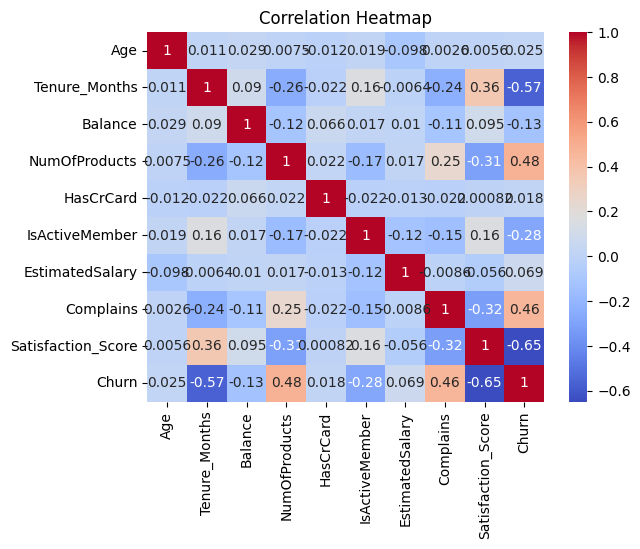

In [95]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [96]:
df.describe()

,Age,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,38.158120,44.863931,71983.431330,1.522293,0.696203,0.566038,107902.893246,0.276074,3.525424,0.250000
std,9.012828,25.328955,45094.852425,0.795171,0.448228,0.484571,41174.021882,0.442551,1.064733,0.433446
min,18.000000,1.000000,53.000000,1.000000,0.000000,0.000000,31782.000000,0.000000,1.000000,0.000000
25%,31.000000,24.000000,34729.500000,1.000000,0.000000,0.000000,76140.000000,0.000000,3.000000,0.000000
50%,38.158120,44.000000,69736.500000,1.000000,1.000000,1.000000,107902.893246,0.000000,3.525424,0.000000
75%,45.000000,65.000000,103280.000000,2.000000,1.000000,1.000000,143412.000000,1.000000,4.000000,0.250000
max,57.000000,95.000000,197316.000000,4.000000,1.000000,1.000000,179621.000000,1.000000,5.000000,1.000000


In [97]:
#Complaining members who are active = 58
mask = df ['Complains'] == 1
df.loc[mask, 'IsActiveMember'].value_counts()

IsActiveMember
0.000000    73
1.000000    58
0.566038     4
Name: count, dtype: int64

<Axes: >

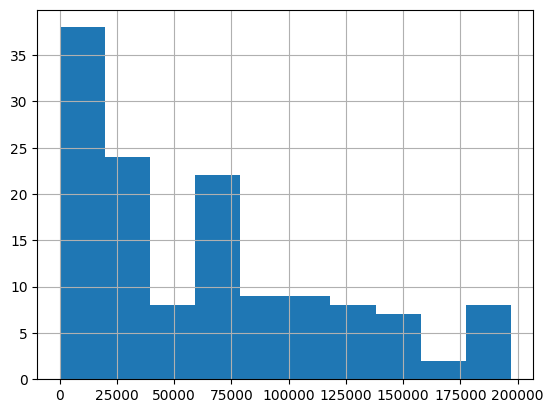

In [98]:
com = df['Complains'] == 1
df.loc[com, 'Balance'].hist()

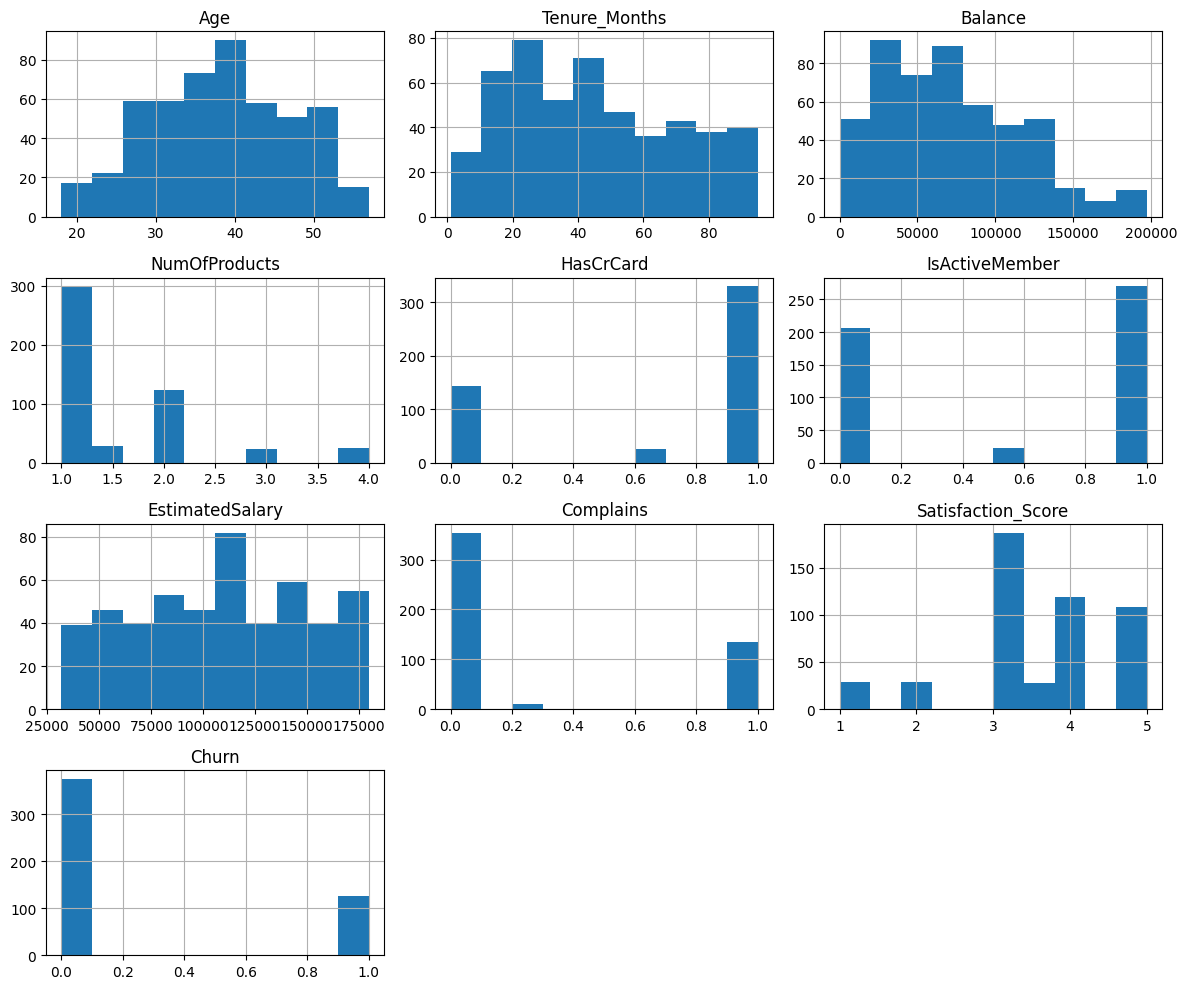

In [99]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Checking for s

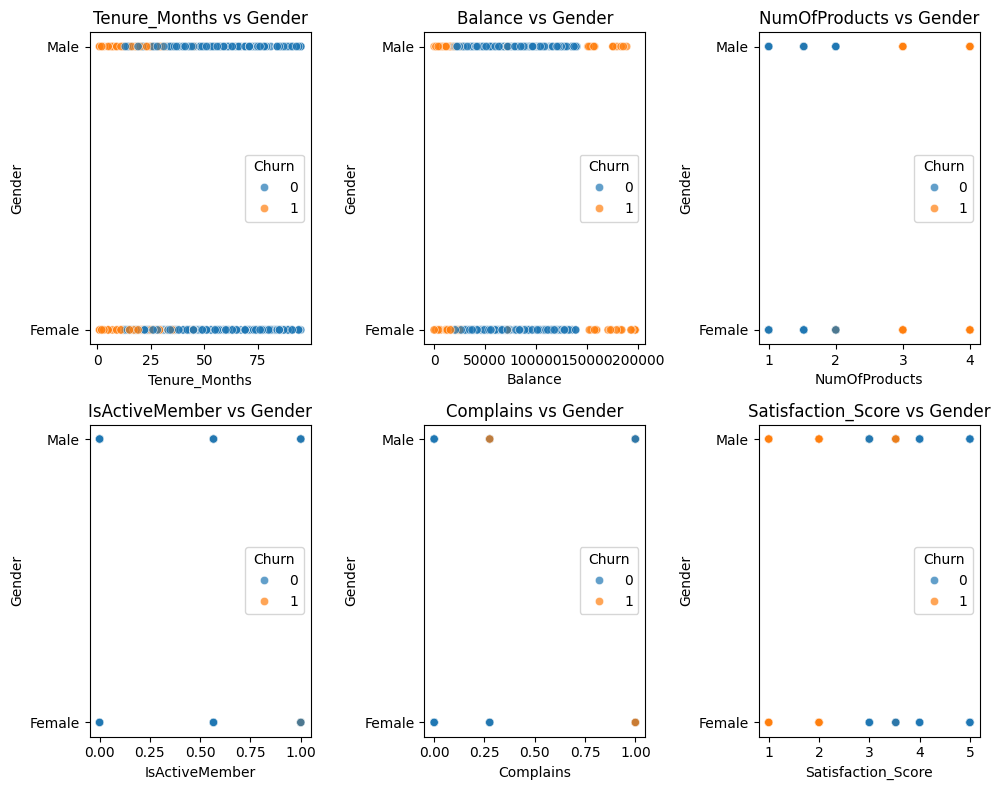

In [100]:
# 1. Choose your vertical axis column and the columns to loop through
y_axis_col = 'Gender'  # Change this to 'Balance', 'CreditScore', etc.
cols_to_plot = df.columns[[3, 4, 5, 7, 9, 10]] 

# 2. Set up a 2x3 grid of plots
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

# 3. Loop through columns and plot each scatter plot
for i, col in enumerate(cols_to_plot):
    # Removed fill=True, added explicit y variable
    sns.scatterplot(data=df, x=col, y=y_axis_col, hue='Churn', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{col} vs {y_axis_col}')

plt.tight_layout()
plt.show()

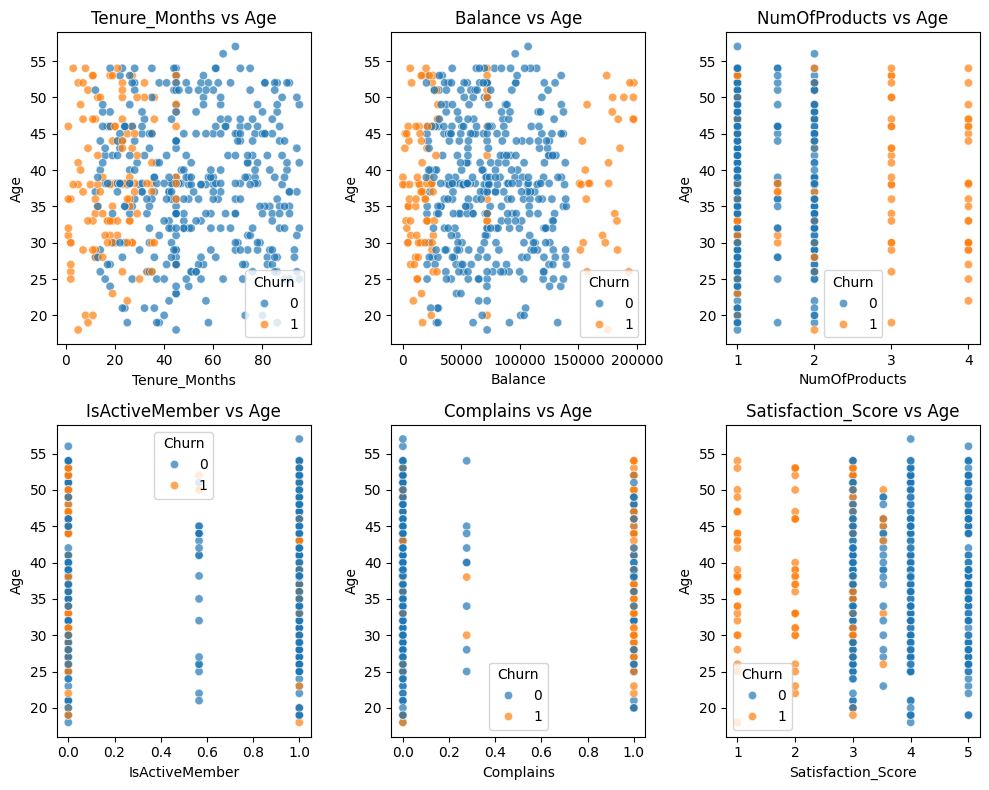

In [101]:
# 1. Choose your vertical axis column and the columns to loop through
y_axis_col = 'Age'  # Change this to 'Balance', 'CreditScore', etc.
cols_to_plot = df.columns[[3, 4, 5, 7, 9, 10]] 

# 2. Set up a 2x3 grid of plots
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

# 3. Loop through columns and plot each scatter plot
for i, col in enumerate(cols_to_plot):
    # Removed fill=True, added explicit y variable
    sns.scatterplot(data=df, x=col, y=y_axis_col, hue='Churn', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{col} vs {y_axis_col}')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_23768\2375031386.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat, y='Churn', ax=axes[i], errorbar=None, palette='Blues_d')
C:\Users\USER\AppData\Local\Temp\ipykernel_23768\2375031386.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat, y='Churn', ax=axes[i], errorbar=None, palette='Blues_d')
C:\Users\USER\AppData\Local\Temp\ipykernel_23768\2375031386.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat, y='Churn', ax=axes[i], errorbar=None, palette=

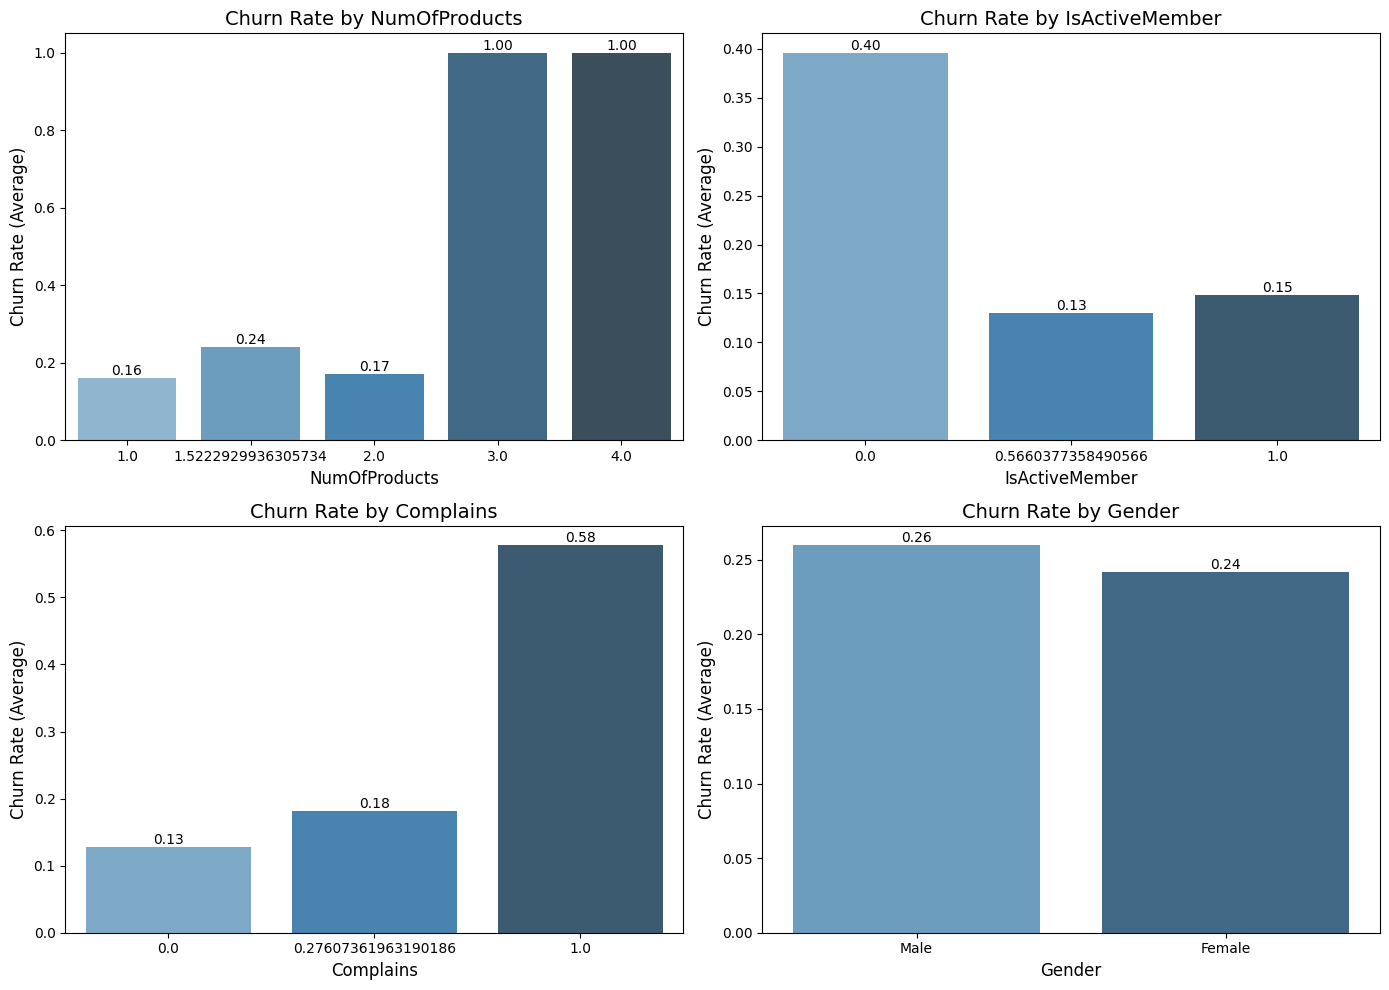

In [102]:

# 1. Define the categorical columns you want to analyze
categories = ['NumOfProducts', 'IsActiveMember', 'Complains', 'Gender'] # Verify 'Complain' vs 'Complains' in your df

# 2. Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 3. Loop through categories and create bar plots
for i, cat in enumerate(categories):
    # y='Churn' automatically calculates the mean (churn rate) for each category
    sns.barplot(data=df, x=cat, y='Churn', ax=axes[i], errorbar=None, palette='Blues_d')
    
    # Format the y-axis as a percentage for easier reading
    axes[i].set_title(f'Churn Rate by {cat}', fontsize=14)
    axes[i].set_ylabel('Churn Rate (Average)', fontsize=12)
    axes[i].set_xlabel(cat, fontsize=12)
    
    # Optional: Add data labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()


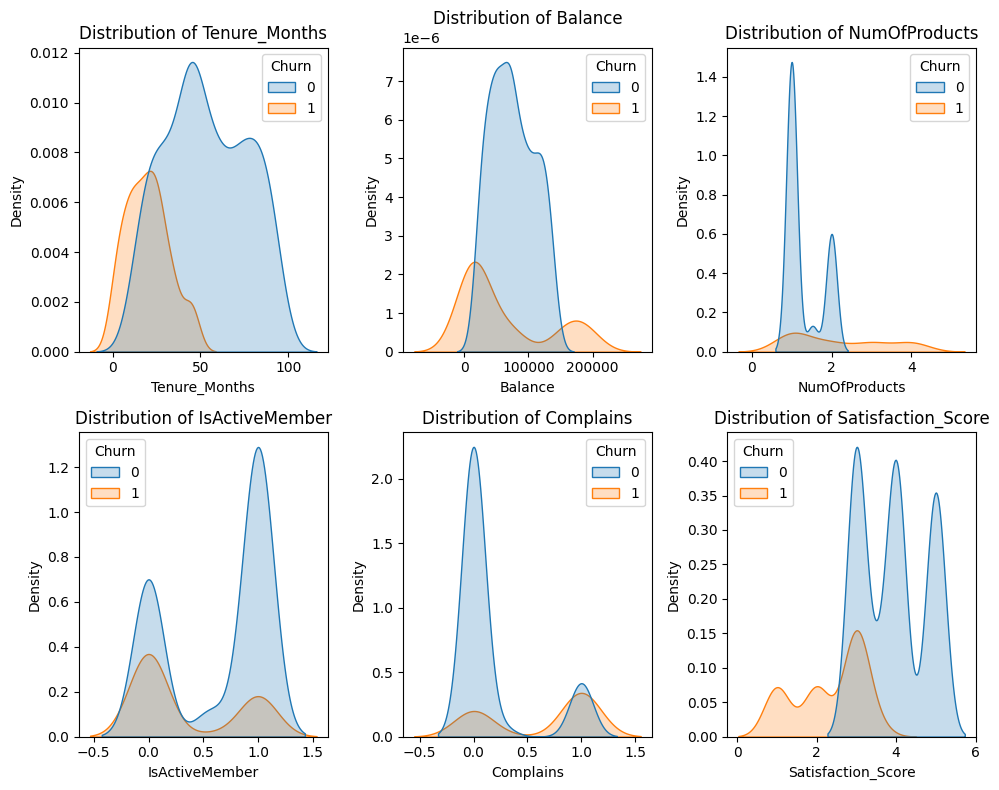

In [103]:

# 1. Define your columns using names (safer than index numbers)
cols_to_plot = df.columns[[3, 4, 5, 7, 9, 10]]

# 2. Set up a grid of plots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()  # Flatten the 2D array of axes to a 1D list

# 3. Loop through columns and plot each one
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(data=df, x=col, hue='Churn', ax=axes[i], fill=True)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


### Taking care of categorical data

In [104]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

### Choosing my features and assigning them to variables of x and y

In [105]:
x = df.iloc[:, [3, 4, 5, 7, 9, 10] ].values
y = df.iloc[:, -1].values
print(x)
print(y)

[[6.70000e+01 5.50320e+04 1.00000e+00 0.00000e+00 0.00000e+00 4.00000e+00]
 [4.60000e+01 5.19020e+04 2.00000e+00 1.00000e+00 0.00000e+00 3.00000e+00]
 [3.00000e+01 1.06468e+05 1.00000e+00 0.00000e+00 0.00000e+00 5.00000e+00]
 ...
 [6.00000e+01 1.01396e+05 1.00000e+00 0.00000e+00 0.00000e+00 3.00000e+00]
 [5.10000e+01 7.91690e+04 1.00000e+00 0.00000e+00 0.00000e+00 5.00000e+00]
 [7.60000e+01 8.49240e+04 2.00000e+00 1.00000e+00 0.00000e+00 3.00000e+00]]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0
 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0
 0 1 0 1 0 1 0 0 0 

### Splitting my dataset

In [106]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

### Creating my model

In [107]:
Powei = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=24)
Powei.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluating my model

In [108]:
y_pred = Powei.predict(x_test)

In [ ]:
#Probability scores. Threshold = > 0.5 likely to churn
Powei.predict_proba(x_test)[:,1]

array([0.  , 0.39, 0.  , 1.  , 1.  , 0.  , 0.  , 0.  , 0.71, 0.  , 0.02,
       0.88, 0.  , 0.83, 0.  , 0.73, 0.  , 0.  , 0.  , 0.  , 0.  , 0.44,
       0.58, 0.  , 0.  , 0.01, 0.01, 0.03, 0.01, 0.44, 0.1 , 0.01, 0.  ,
       0.5 , 0.88, 0.74, 0.68, 0.04, 0.06, 0.01, 0.  , 0.  , 0.  , 0.11,
       0.  , 0.01, 0.  , 0.84, 0.65, 0.  , 0.  , 0.  , 0.01, 0.01, 1.  ,
       0.  , 0.15, 0.  , 0.96, 0.99, 0.03, 0.07, 0.  , 0.94, 0.16, 0.86,
       0.11, 0.  , 0.  , 0.01, 0.  , 0.  , 0.01, 0.01, 0.  , 0.33, 0.  ,
       0.  , 0.  , 0.  , 0.52, 1.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.99, 0.69, 0.  , 0.99, 0.95, 0.01, 0.  , 0.  , 0.26,
       0.14])

### Feature importance

In [109]:
features = ['Tenure_Months', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Complains', 'Satisfaction_Score']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': Powei.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

              Feature  Importance
0       Tenure_Months    0.295722
5  Satisfaction_Score    0.290998
1             Balance    0.262876
2       NumOfProducts    0.076734
4           Complains    0.056589
3      IsActiveMember    0.017081


### Visualizing my first tree

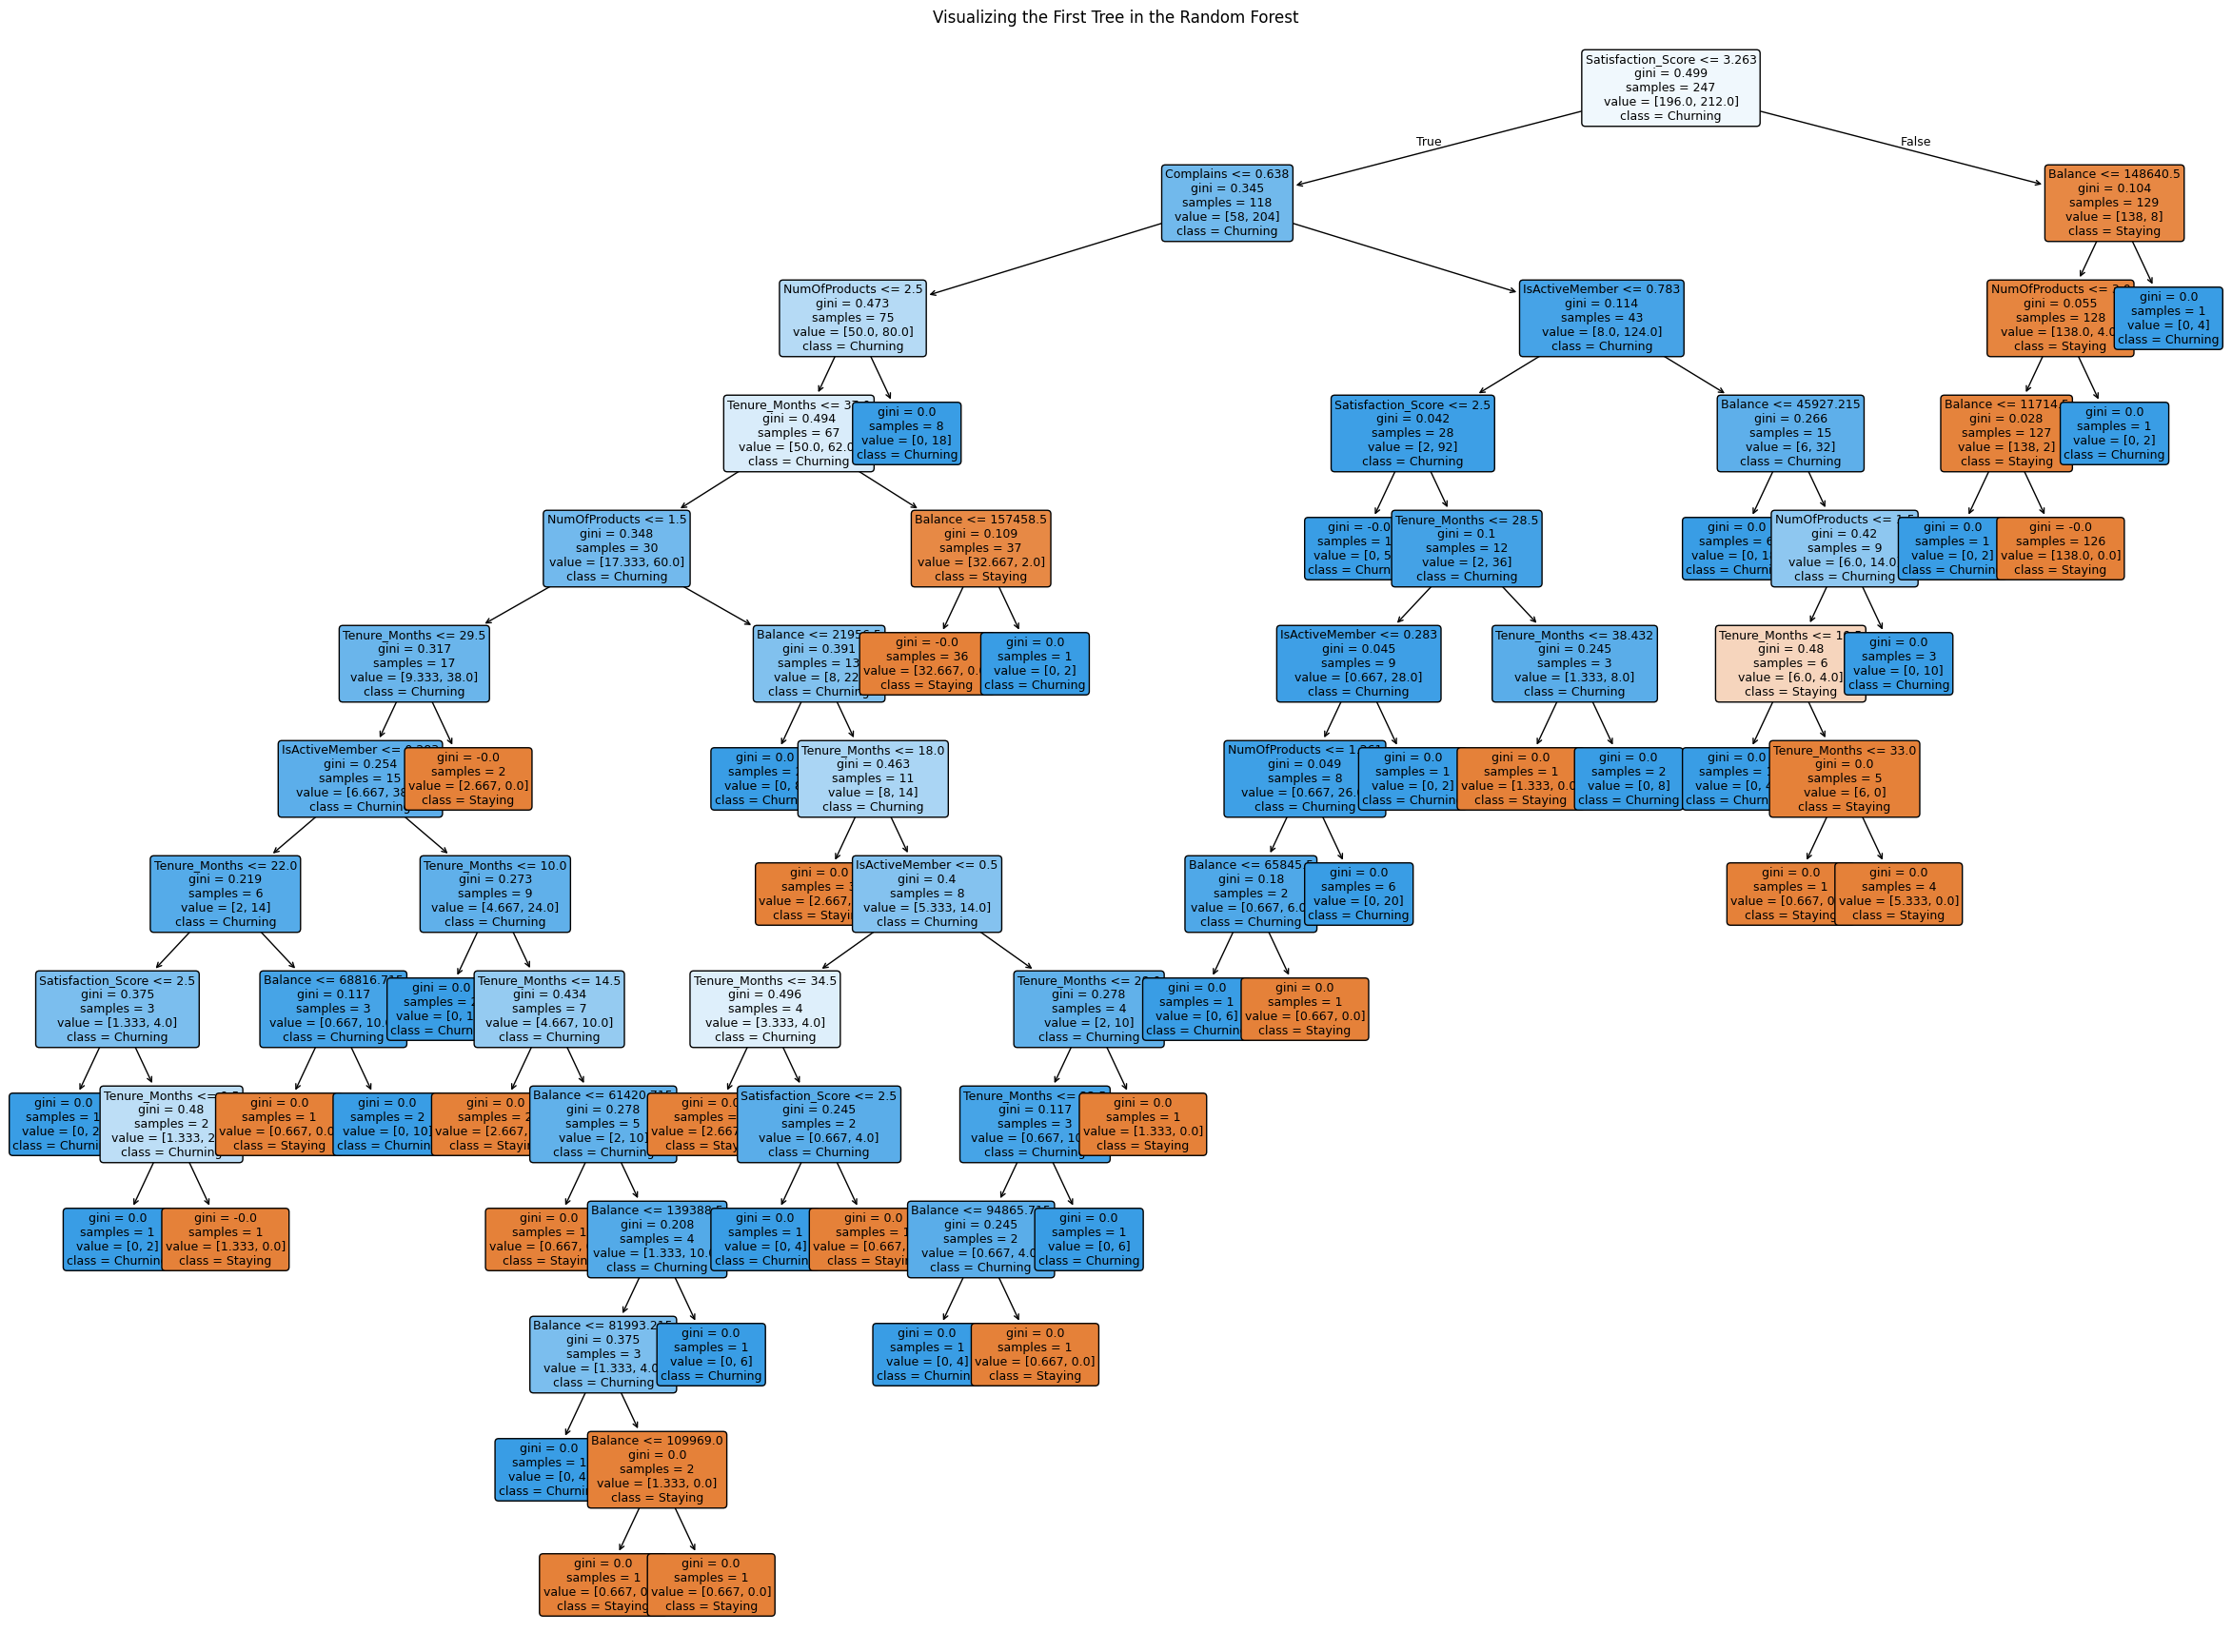

In [110]:
features = ['Tenure_Months', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Complains', 'Satisfaction_Score']
tree_to_plot = Powei.estimators_[0] 
plt.figure(figsize=(30,22))
plot_tree(tree_to_plot, 
          feature_names=features, 
          class_names=['Staying', 'Churning'], 
          filled=True, 
          rounded=True,
          fontsize=9)
plt.title("Visualizing the First Tree in the Random Forest")
plt.savefig('Powei_Microfinance_Bank.png')
plt.show()

In [114]:
#Clustering


# Use the same features
x_cluster = df[['Age', 'Gender', 'Tenure_Months', 'Balance', 'Satisfaction_Score', 'NumOfProducts', 'Complains', 'IsActiveMember']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

# Find best K
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    print(f"k={k}, silhouette={silhouette_score(x_scaled, labels):.4f}")

k=2, silhouette=0.2413
k=3, silhouette=0.1572
k=4, silhouette=0.1731
k=5, silhouette=0.1666
k=6, silhouette=0.1670
k=7, silhouette=0.1908


In [115]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = km_final.fit_predict(x_scaled)

In [116]:
print(pd.crosstab(df['Segment'], df['Churn'], normalize='index').round(2))

Churn       0     1
Segment            
0        0.10  0.90
1        0.93  0.07
2        0.92  0.08


In [117]:
df.groupby('Segment')[['Tenure_Months','Balance','Satisfaction_Score']].mean().round(2)

,Tenure_Months,Balance,Satisfaction_Score
Segment,,,
0,19.36,50202.82,2.33
1,51.04,79950.16,3.86
2,52.15,75950.65,3.83


### Report documentation

This model was built on behalf of Powei Microfinance Bank using data of recent churning by customers. The bank wanted to put a stop to this trend. The data contained 12 columns and 500 rows. The goal was to build a model that would be able to predict if customer will stay or churn.

After carrying out my EDA, I discovered some missing data and quickly fixed them. From my EDA, I quickly discovered that most of the proposed features such as Age, Gender, Estimated Salary and Has Credit Card had zero correlation with my proposed target 'Churn'. Despite some of them having a good variance (Explain varaince), I decided to leave them out because of the 0 correlation. Balance had a low correlation but had to be add because it's variance level made a good case for it, and at the end, it showed to be an excellent decision, because it turned out to be an important feature with 0.26 importance level.

The feature importance list can be seen below;
    Feature                             Importance
0   Tenure_Months                       0.295722
1   Satisfaction_Score                  0.290998
2   Balance                             0.262876
3   NumOfProducts                       0.076734
4   Complains                           0.056589
5   IsActiveMember                      0.017081

The model should be perfect for this job because it has a accurate score of 98% with an excellent precision, recall and f1 score. The features used were Tenure_Months, Balance, Number Of Products, Is an Active Member, Complains,and Satisfaction_Score. 
From the importance list above, the following features; Tenure_Months, Satisfaction_Score, Balance, Number Of Products are key to predicting any future customer churning activity.

### Recommendation

To reduce customer churn, I recommend that Powei Microfinance Bank should focus on strengthening early customer relationships, and actively monitor customer satisfaction. 
Customers with shorter tenure, lower satisfaction scores, and low balances are more likely to churn easily. By offering welcome programs, resolving complaints quickly, and promoting additional products or savings incentives, the bank can make customers feel valued and invested.

Report
This model was built for Powei Microfinance Bank following a recent mass churn of customers. The bank needed a way to predict which customers were likely to churn next, so intervention could happen before the exit. The dataset contained 500 rows and 12 columns.
After running my EDA, I identified missing values across several columns and handled them — categorical nulls filled by mode, numerical nulls by mean. I also discovered early that features like Age, Gender, EstimatedSalary, and HasCrCard showed zero correlation with the target variable (Churn), and despite some showing reasonable variance, I excluded them. Balance was the one exception — low correlation on paper, but its variance made a strong case for inclusion, and that decision paid off.
The six features selected were: Tenure_Months, Balance, NumOfProducts, IsActiveMember, Complains, and Satisfaction_Score.
Feature importance results confirmed the selection was sound:
FeatureImportanceTenure_Months0.2957Satisfaction_Score0.2910Balance0.2629NumOfProducts0.0767Complains0.0566IsActiveMember0.0171
The Random Forest Classifier was trained with class_weight='balanced' to account for any class imbalance, and the model returned a 98% accuracy with strong precision, recall, and F1 scores across both classes. Tenure, satisfaction, and balance are the top three predictors — together accounting for over 85% of the model's decision-making weight.

Recommendation
To reduce customer churn, Powei Microfinance Bank should prioritise three things: early relationship building, satisfaction monitoring, and balance growth incentives.
The data is clear — customers with short tenure, low satisfaction scores, and low balances are the most likely to leave. These are not random exits; they are customers who never felt invested in the bank, and the bank never gave them a reason to stay.
My recommendation is to implement a structured onboarding programme for new customers within their first three months, since tenure is the single strongest churn predictor. Pair that with a complaint resolution tracker — unresolved complaints are a quiet churn driver that compounds over time. For low-balance customers, targeted savings incentives or product bundling (the data shows NumOfProducts matters) can increase stickiness before disengagement sets in.
The bank should also use the model's churn probability scores — not just the binary prediction — to tier customers by risk level and deploy retention resources where they matter most.